En este proyecto se intentará simular una situación real de un cliente solicitando un servicio de analítica a partir de la información que dispone. 

Prompt:

Simula una situación donde eres un cliente que quiere contratar un servicio de analítica de datos a partir de información disponible que posees. Los datos que posees tienen las siguientes columnas:

---columnas---

Ship Mode	Segment	Country	City	State	Postal Code	Region	Category	Sub-Category	Sales	Quantity	Discount	Profit



---Instrucciones---

Dame los requisitos del proyecto:

- Objetivos aproximados o noción de estos (Ten en cuenta que el cliente tal vez no tenga ni idea de qué hacer con sus datos o puede tener una noción). Pueden ser múltiples, desde información descriptiva hasta información a partir del modelado estadistico o machine learning
- Entregables esperados (aproximados)
- Tiempo de entrega 
- Recursos disponibles


# 1.- Entender el problema y definir el objetivo

📌 Contexto del cliente (simulación)

Soy una empresa que vende productos a nivel nacional y tengo un registro de mis ventas en una base de datos. Cada fila representa una transacción y contiene información como el modo de envío, el segmento del cliente, la ciudad, el estado, la región, la categoría y subcategoría del producto, además de las métricas de ventas, cantidad, descuento y ganancia.

No sé exactamente qué tan profundo puedo llegar con este análisis, pero quiero aprovechar estos datos para entender mejor mi negocio y tomar decisiones más inteligentes.

## 1.1.- Objetivos aproximados

1. **Análisis descriptivo:**
    - Identificar patrones de ventas por región, estado y ciudad.
    - Analizar cuáles son los productos y categorías más rentables.
    - Ver el impacto de los descuentos en las ganancias.
    - Detectar tendencias de compra por segmento de cliente.
2. **Análisis diagnóstico:**
    - Entender por qué ciertas regiones o productos tienen márgenes más bajos.
    - Evaluar si el modo de envío influye en el margen de ganancia.
3. **Análisis predictivo / estadístico (en caso de ser posible):**
    - Predecir ventas futuras por región o categoría usando series de tiempo o modelos de machine learning.
    - Identificar clientes o segmentos con mayor probabilidad de compras repetidas.
4. **Análisis prescriptivo (opcional):**
    - Recomendaciones sobre asignación de inventario o ajustes de descuentos para maximizar beneficios.

## 1.2.- Entregables esperados (aproximados)

- **Dashboard interactivo** (en Power BI, Tableau o similar) con:
    - Ventas, ganancia y cantidad por región, ciudad, categoría y subcategoría.
    - Análisis de descuentos y su impacto en las ganancias.
    - Segmentación de clientes y patrones de compra.
- **Informe escrito** con hallazgos clave y conclusiones.
- **Modelos predictivos** (si aplican) con métricas de desempeño y escenarios simulados.
- **Recomendaciones accionables** para mejorar márgenes y priorizar ventas.

## 1.3.- Recursos disponibles

**Datos:**
- Archivo CSV/Excel con las columnas mencionadas y varios años de historial.

**Herramientas disponibles:**
- Microsoft Excel
- Power BI 
- Posibilidad de usar Python o R (instalados)

**Personal de apoyo:**
- Contacto interno para resolver dudas sobre los datos y su origen.

**Presupuesto:**
- Flexible, pero se requiere una propuesta con desglose de costos.

# 2.- Obtener los datos

In [2]:

#importar librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [3]:
import pandas as pd

df_original = pd.read_csv("ventas_original.csv")
df_original.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 2.1.- Entender cada columna o variable

La tabla original:

| **Nombre en Español** | **Nombre en Inglés** | **Descripción**                                                                                                   |
| --------------------- | -------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Modo\_de\_envío**   | Ship Mode            | Tipo de servicio de envío utilizado para la entrega del pedido (ejemplo: Standard Class, Second Class, Same Day). |
| **Segmento**          | Segment              | Tipo de cliente al que se le realizó la venta (Consumer, Corporate, Home Office).                                 |
| **País**              | Country              | País en el cual se efectuó la venta (en este dataset: United States).                                             |
| **Ciudad**            | City                 | Ciudad en la que reside el cliente o se entregó el pedido.                                                        |
| **Estado**            | State                | Estado o provincia dentro del país donde se ubica el cliente.                                                     |
| **Código\_Postal**    | Postal Code          | Código postal de la dirección de envío del cliente.                                                               |
| **Región**            | Region               | División geográfica del país (South, West, East, Central).                                                        |
| **Categoría**         | Category             | Clasificación principal del producto vendido (Furniture, Office Supplies, Technology).                            |
| **Subcategoría**      | Sub-Category         | Subdivisión más específica de la categoría de producto (Bookcases, Chairs, Labels, Tables, etc.).                 |
| **Ventas**            | Sales                | Valor monetario de la venta (ingresos generados por el pedido).                                                   |
| **Cantidad**          | Quantity             | Número de unidades de producto vendidas en el pedido.                                                             |
| **Descuento**         | Discount             | Porcentaje de descuento aplicado a la venta (ejemplo: 0.20 = 20% de descuento).                                   |
| **Ganancia**          | Profit               | Utilidad neta obtenida tras la venta (Ventas - Costos - Descuentos).                                              |


Podemos normalizar la tabla con fines de tener mejor integridad en los datos. Una primera propuesta a la normalización de la tabla se encuentra en el archivo SQL adjunto en esta carpeta

In [6]:
# Cambiar los nombres de las columnas a español
df_original.columns = [
    'Modo_de_envío', 'Segmento', 'País', 'Ciudad', 'Estado', 'Código_Postal',
    'Región', 'Categoría', 'Subcategoría', 'Ventas', 'Cantidad', 'Descuento', 'Ganancia'
]
df_original.head()

,Modo_de_envío,Segmento,País,Ciudad,Estado,Código_Postal,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
# Save the original DataFrame to a new CSV file
df_original.to_csv("ventas_original_español.csv", index=False)


# 3.- Exploración del dataset

In [3]:
df_original = pd.read_csv("ventas_original_español.csv")
df_original.head()

,Modo_de_envío,Segmento,País,Ciudad,Estado,Código_Postal,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164



1. TAMAÑO DEL DATAFRAME
(9994, 13)

2. INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Modo_de_envío  9994 non-null   object 
 1   Segmento       9994 non-null   object 
 2   País           9994 non-null   object 
 3   Ciudad         9994 non-null   object 
 4   Estado         9994 non-null   object 
 5   Código_Postal  9994 non-null   int64  
 6   Región         9994 non-null   object 
 7   Categoría      9994 non-null   object 
 8   Subcategoría   9994 non-null   object 
 9   Ventas         9994 non-null   float64
 10  Cantidad       9994 non-null   int64  
 11  Descuento      9994 non-null   float64
 12  Ganancia       9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB

3. DICCIONARIO DE CATEGORÍAS (VARIABLES CATEGÓRICAS)

Columna: Modo_de_envío
Categorías: ['Seco

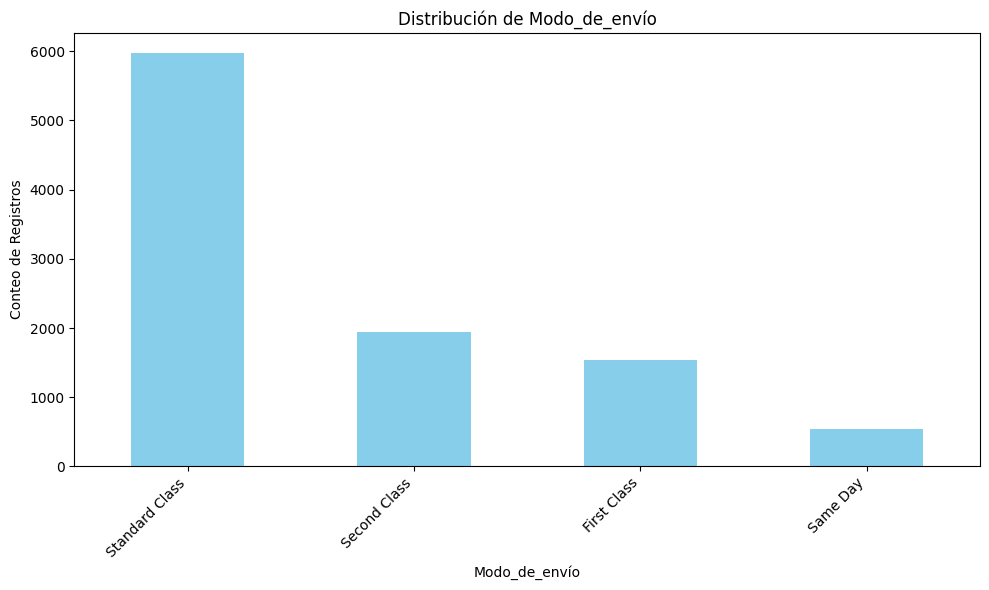

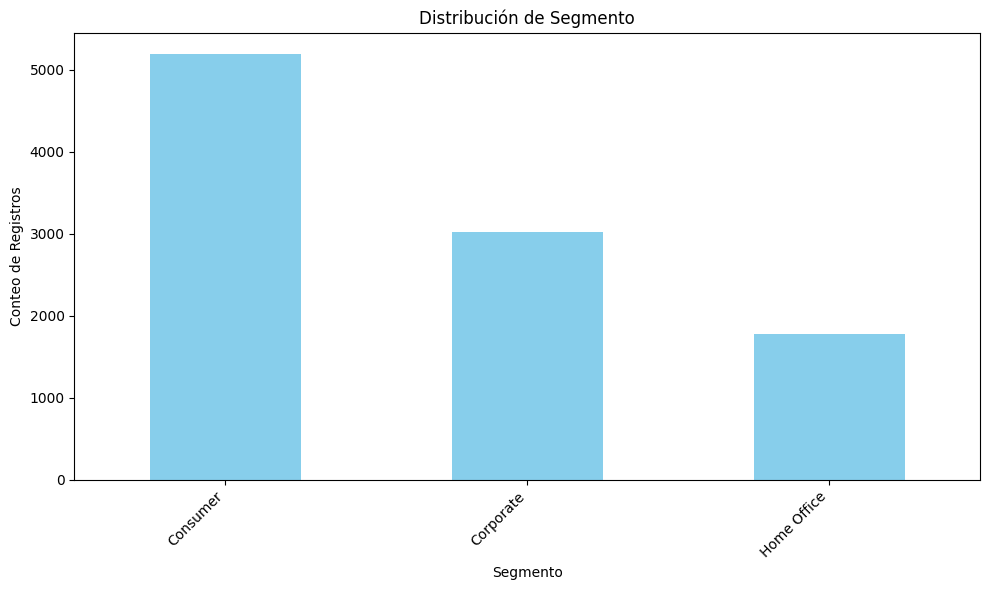

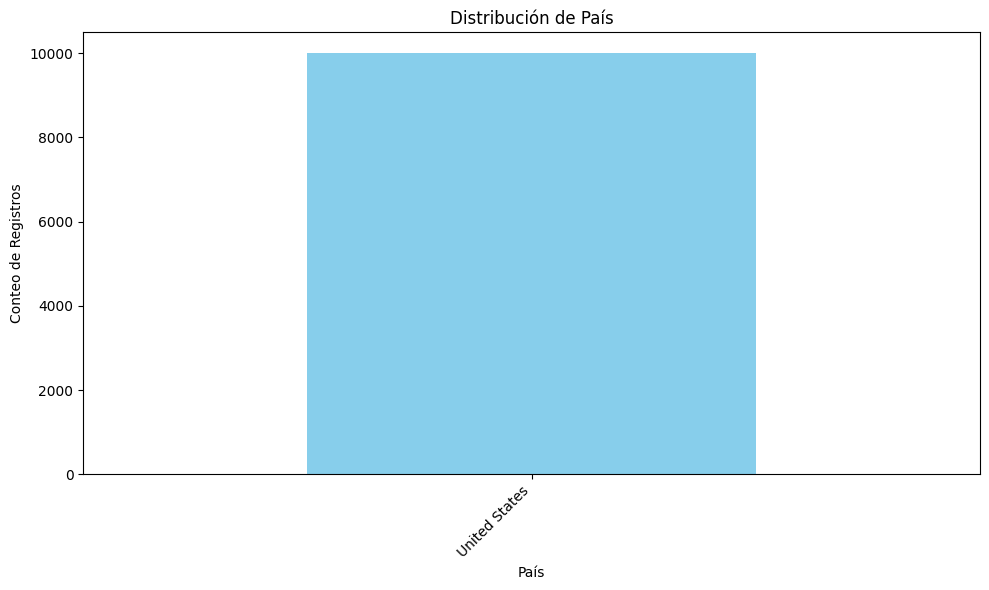

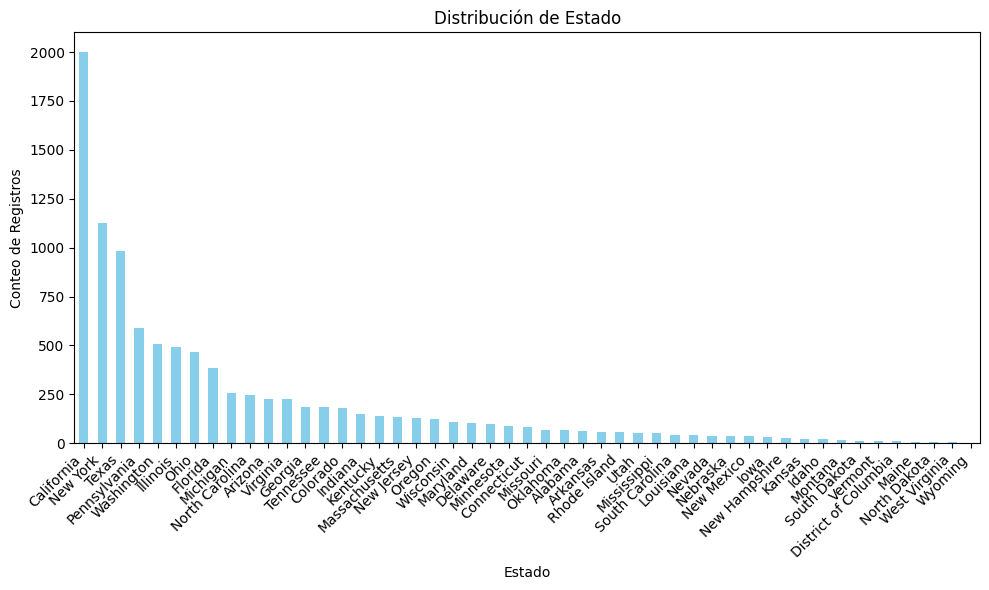

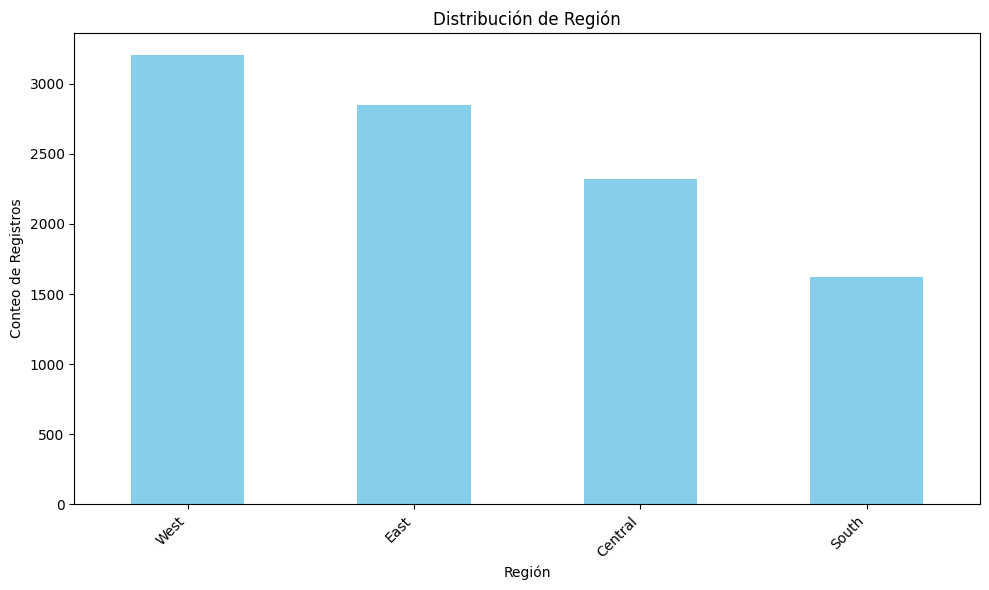

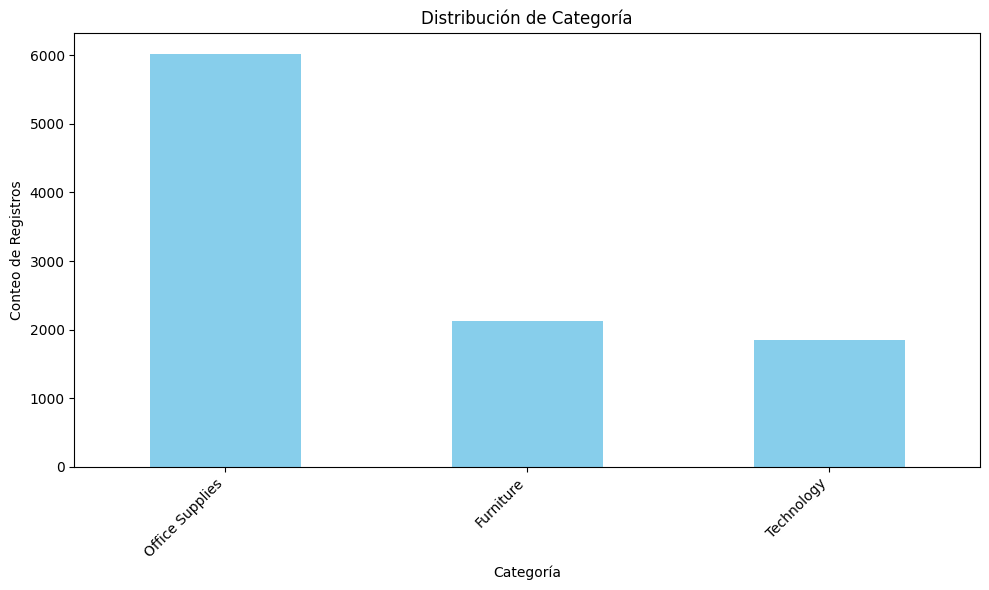

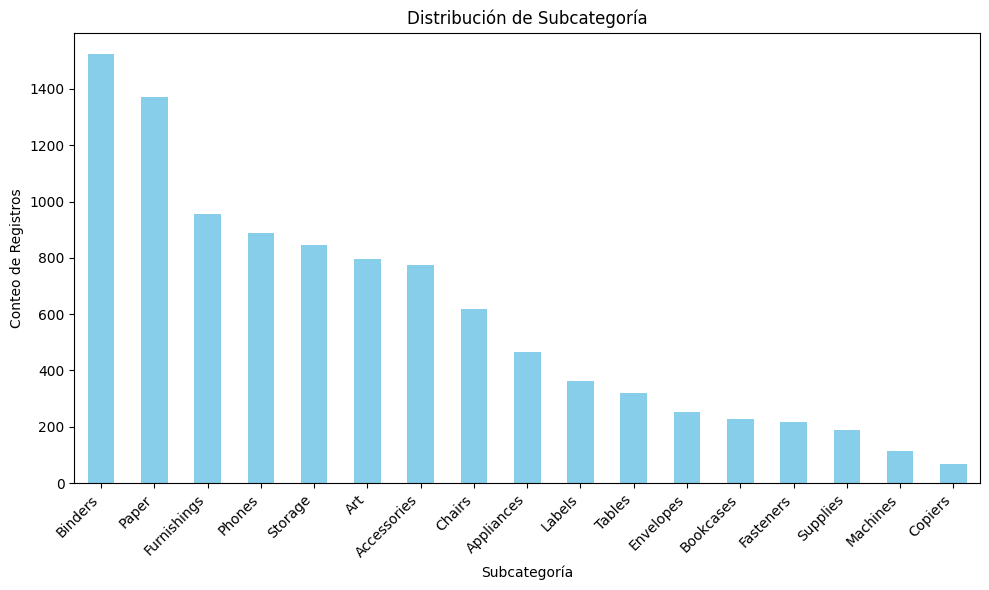


4. ESTADÍSTICAS DESCRIPTIVAS
       Código_Postal        Ventas     Cantidad    Descuento     Ganancia
count    9994.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean    55190.379428    229.858001     3.789574     0.156203    28.656896
std     32063.693350    623.245101     2.225110     0.206452   234.260108
min      1040.000000      0.444000     1.000000     0.000000 -6599.978000
25%     23223.000000     17.280000     2.000000     0.000000     1.728750
50%     56430.500000     54.490000     3.000000     0.200000     8.666500
75%     90008.000000    209.940000     5.000000     0.200000    29.364000
max     99301.000000  22638.480000    14.000000     0.800000  8399.976000

5. VALORES FALTANTES
Modo_de_envío    0
Segmento         0
País             0
Ciudad           0
Estado           0
Código_Postal    0
Región           0
Categoría        0
Subcategoría     0
Ventas           0
Cantidad         0
Descuento        0
Ganancia         0
dtype: int64

6. DETECCIÓN DE OUTLI

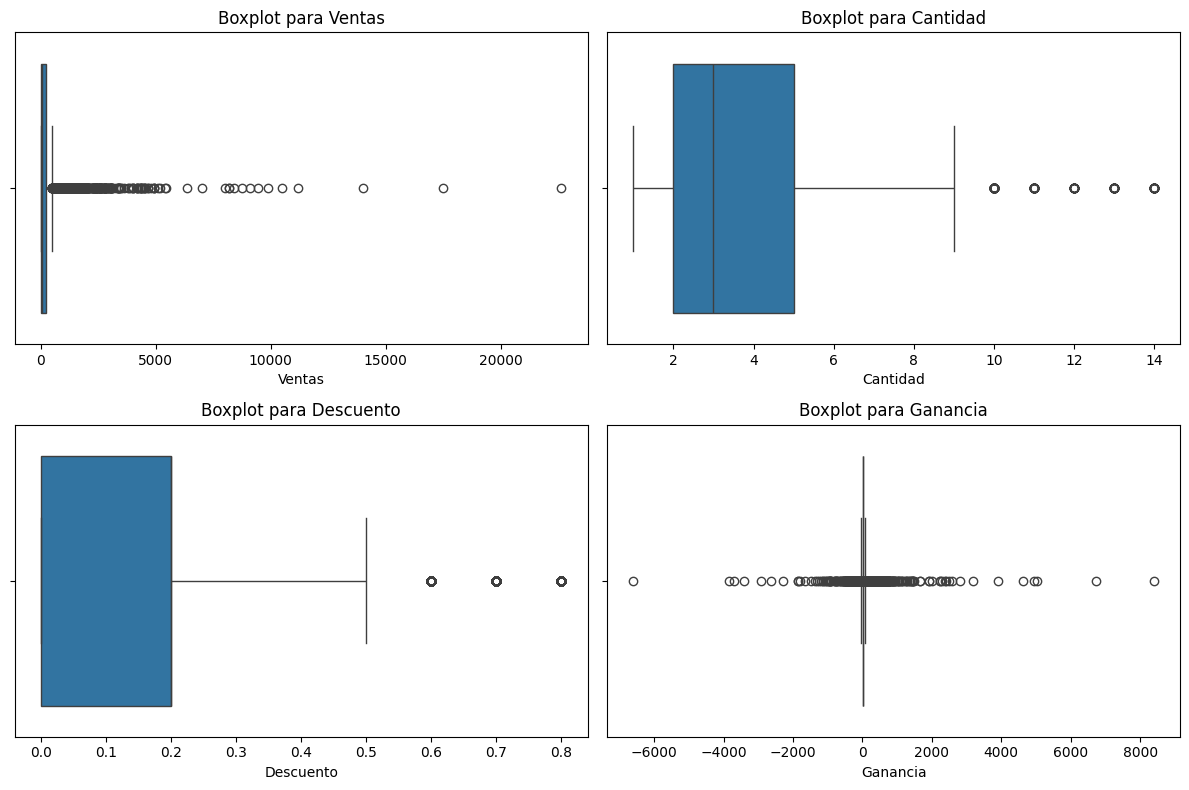


7. MATRIZ DE CORRELACIÓN


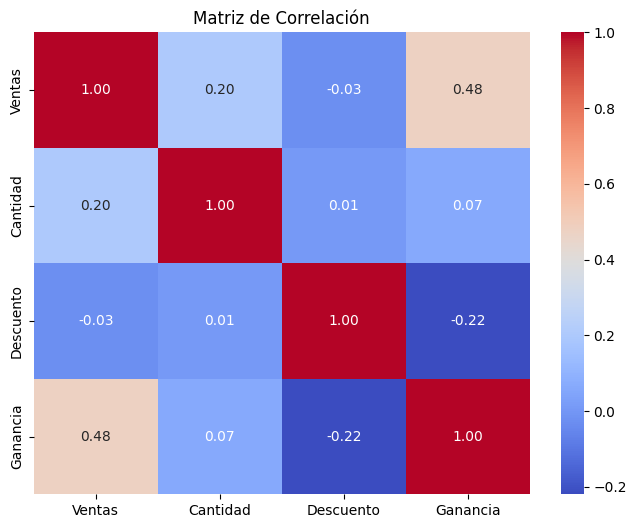


7.1. MATRIZ DE DISPERSIÓN (PAIRPLOT)


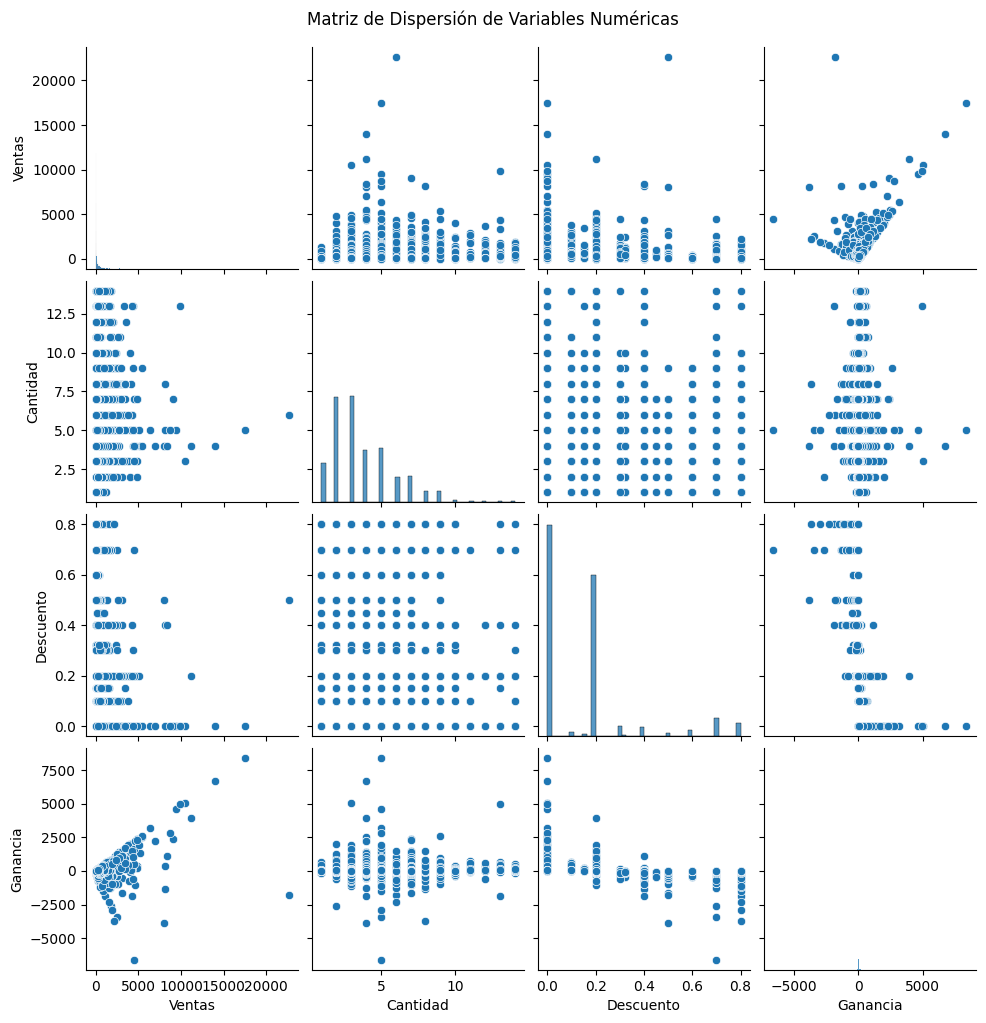


8. DISTRIBUCIÓN DE DATOS (QQ-PLOT)


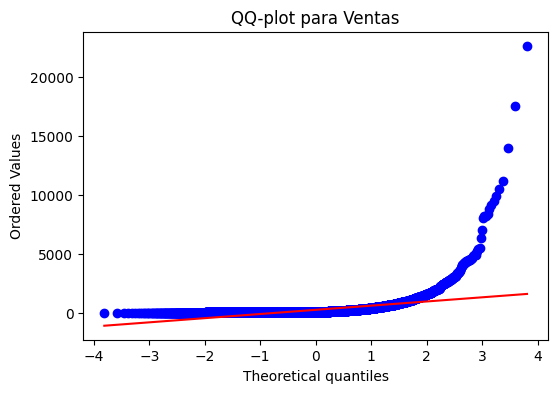

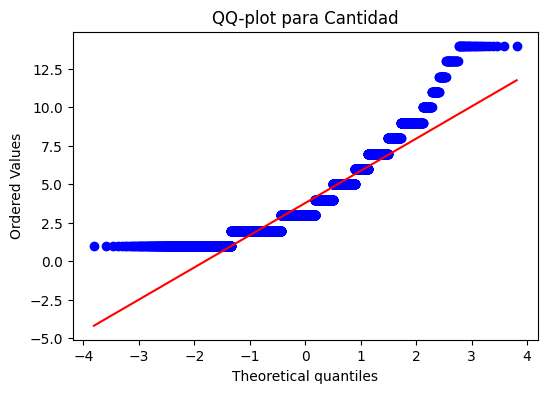

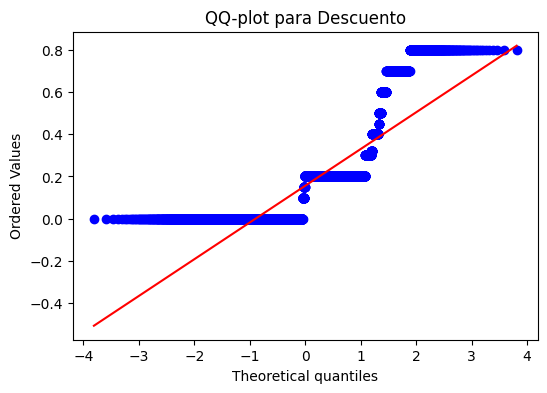

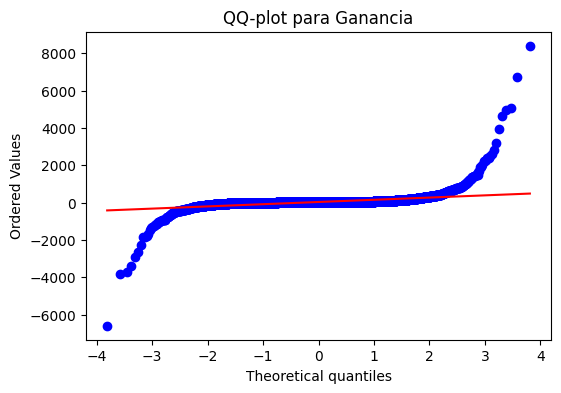


8.1. DISTRIBUCIÓN DE DATOS NUMÉRICOS (HISTOGRAMAS Y KDE)


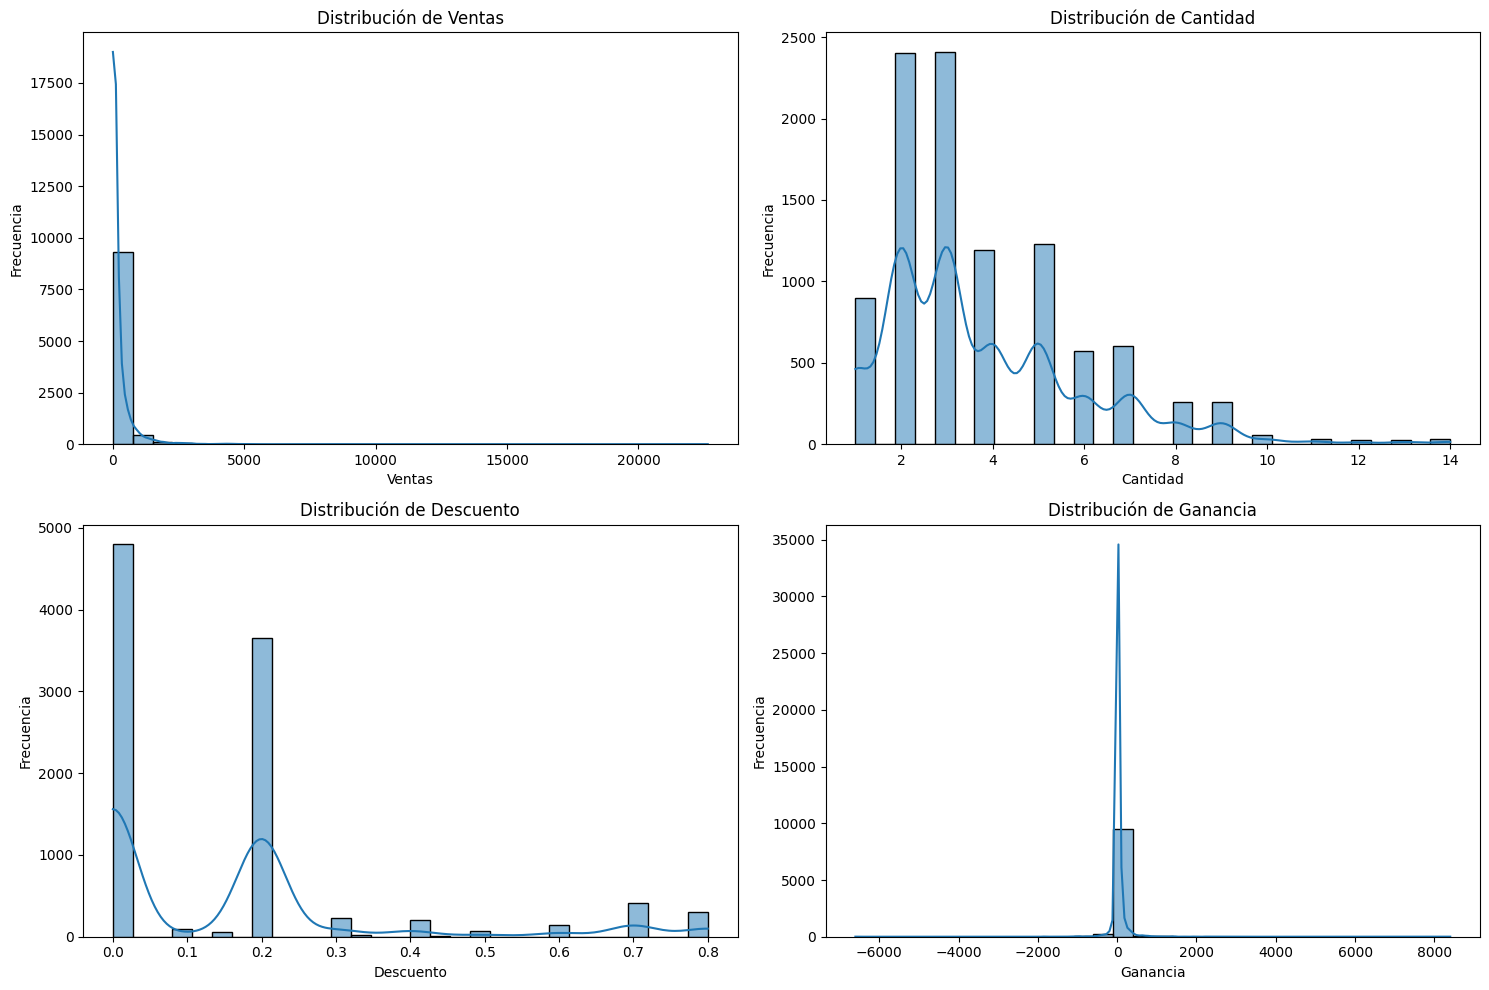

In [8]:
# =====================================================
# PIPELINE DE EXPLORACIÓN DE DATOS
# =====================================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# ===============================
# 1. Tamaño del DataFrame
# ===============================
print("\n" + "="*50)
print("1. TAMAÑO DEL DATAFRAME")
print("="*50)
print(df_original.shape)


# ===============================
# 2. Información general del dataset
# ===============================
print("\n" + "="*50)
print("2. INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
df_original.info()


# ===============================
# 3. Diccionario de categorías por columna (categóricas)
# ===============================
print("\n" + "="*50)
print("3. DICCIONARIO DE CATEGORÍAS (VARIABLES CATEGÓRICAS)")
print("="*50)

columnas_categoricas = [
    'Modo_de_envío', 'Segmento', 'País', 'Ciudad', 
    'Estado', 'Región', 'Categoría', 'Subcategoría'
]

categorias_por_columna = {col: df_original[col].unique().tolist() 
                          for col in columnas_categoricas}

for col, categorias in categorias_por_columna.items():
    print(f"\nColumna: {col}")
    print(f"Categorías: {categorias}")



# ===============================
# 3.1. Análisis de Frecuencia y Visualización (Variables Categóricas)
# ===============================
print("\n" + "="*50)
print("3.1. FRECUENCIA Y VISUALIZACIÓN DE VARIABLES CATEGÓRICAS")
print("="*50)

# Lista de columnas categóricas definida previamente
columnas_categoricas = [
    'Modo_de_envío', 'Segmento', 'País', 
    'Estado', 'Región', 'Categoría', 'Subcategoría'
]


# Itera sobre cada columna categórica para generar un diagrama de barras
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6)) # Define el tamaño de la figura para cada gráfico
    
    # Crea el diagrama de barras de la frecuencia de valores
    # 'value_counts()' cuenta las ocurrencias de cada categoría
    # 'plot(kind='bar')' genera el gráfico de barras
    df_original[col].value_counts().plot(kind='bar', color='skyblue')
    
    # Agrega el título del gráfico, usando el nombre de la columna
    plt.title(f'Distribución de {col}')
    
    # Etiqueta del eje X, usando el nombre de la columna
    plt.xlabel(col)
    
    # Etiqueta del eje Y
    plt.ylabel('Conteo de Registros')
    
    # Rota las etiquetas del eje X si son muy largas para evitar superposiciones
    plt.xticks(rotation=45, ha='right')
    
    # Ajusta el layout para que no se corten las etiquetas
    plt.tight_layout()
    
    # Muestra el gráfico
    plt.show()




# ===============================
# 4. Estadísticas descriptivas (numéricas)
# ===============================
print("\n" + "="*50)
print("4. ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
print(df_original.describe())


# ===============================
# 5. Valores faltantes por columna
# ===============================
print("\n" + "="*50)
print("5. VALORES FALTANTES")
print("="*50)
print(df_original.isnull().sum())


# ===============================
# 6. Detección de valores atípicos (IQR)
# ===============================
print("\n" + "="*50)
print("6. DETECCIÓN DE OUTLIERS (IQR)")
print("="*50)

columnas_numericas = ['Ventas', 'Cantidad', 'Descuento', 'Ganancia']
total_datos = df_original.shape[0]

for col in columnas_numericas:
    Q1 = df_original[col].quantile(0.25)
    Q3 = df_original[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_original[(df_original[col] < lower_bound) | 
                           (df_original[col] > upper_bound)][col]
    num_outliers = outliers.count()
    porcentaje_outliers = (num_outliers / total_datos) * 100
    
    print(f"Columna: {col}")
    print(f"   Número de outliers: {num_outliers}")
    print(f"   Porcentaje: {porcentaje_outliers:.2f}%\n")


# ahora con graficos de caja 

plt.figure(figsize=(12, 8))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_original[col])
    plt.title(f'Boxplot para {col}')
plt.tight_layout()
plt.show()


# ===============================
# 7. Matriz de correlación
# ===============================
print("\n" + "="*50)
print("7. MATRIZ DE CORRELACIÓN")
print("="*50)

matriz_correlacion = df_original[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


# ===============================
# 7.1. Matriz de dispersión (Pairplot)
# ===============================
print("\n" + "="*50)
print("7.1. MATRIZ DE DISPERSIÓN (PAIRPLOT)")
print("="*50)

# Esto puede tomar un tiempo si tienes muchas columnas numéricas.
# Puedes seleccionar un subconjunto si es necesario.
sns.pairplot(df_original[columnas_numericas])
plt.suptitle('Matriz de Dispersión de Variables Numéricas', y=1.02)
plt.show()



# ===============================
# 8. Distribución de datos (QQ-plot)
# ===============================
print("\n" + "="*50)
print("8. DISTRIBUCIÓN DE DATOS (QQ-PLOT)")
print("="*50)

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    stats.probplot(df_original[col], dist="norm", plot=plt)
    plt.title(f'QQ-plot para {col}')
    plt.show()


# ===============================
# 8.1. Distribución de datos numéricos (Histogramas y KDE)
# ===============================
print("\n" + "="*50)
print("8.1. DISTRIBUCIÓN DE DATOS NUMÉRICOS (HISTOGRAMAS Y KDE)")
print("="*50)

plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_original[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()